<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Custom_Multi_Band_Tight_Binding_Model_Solver_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x scipy

GPU: NVIDIA L4; CuPy 14.0.1
CUDA runtime: 12090

Graphene: illustrative orthogonal sp3 model
Bloch/CSR error 4.62e-14 eV; analytic pi error 4.44e-15 eV
float32/float64 maximum moment difference: 1.76e-06
Sparse lowest-edge error: 9.59e-14 eV
Conservative working-memory estimate: 46.2 MiB
Components 5: dense [4, 2, 2]; sparse [7776, 2592]
Selected order 512; DOS area 1.000000
Order criterion: maximum order reached
DOS wall time: 1.61 s; orbitals 10,376; stored entries 69,998
Analytic K-point pi gap: 0.000 eV (model parameter result)
Sampled eight-band half-filling gap: 0.0000 eV


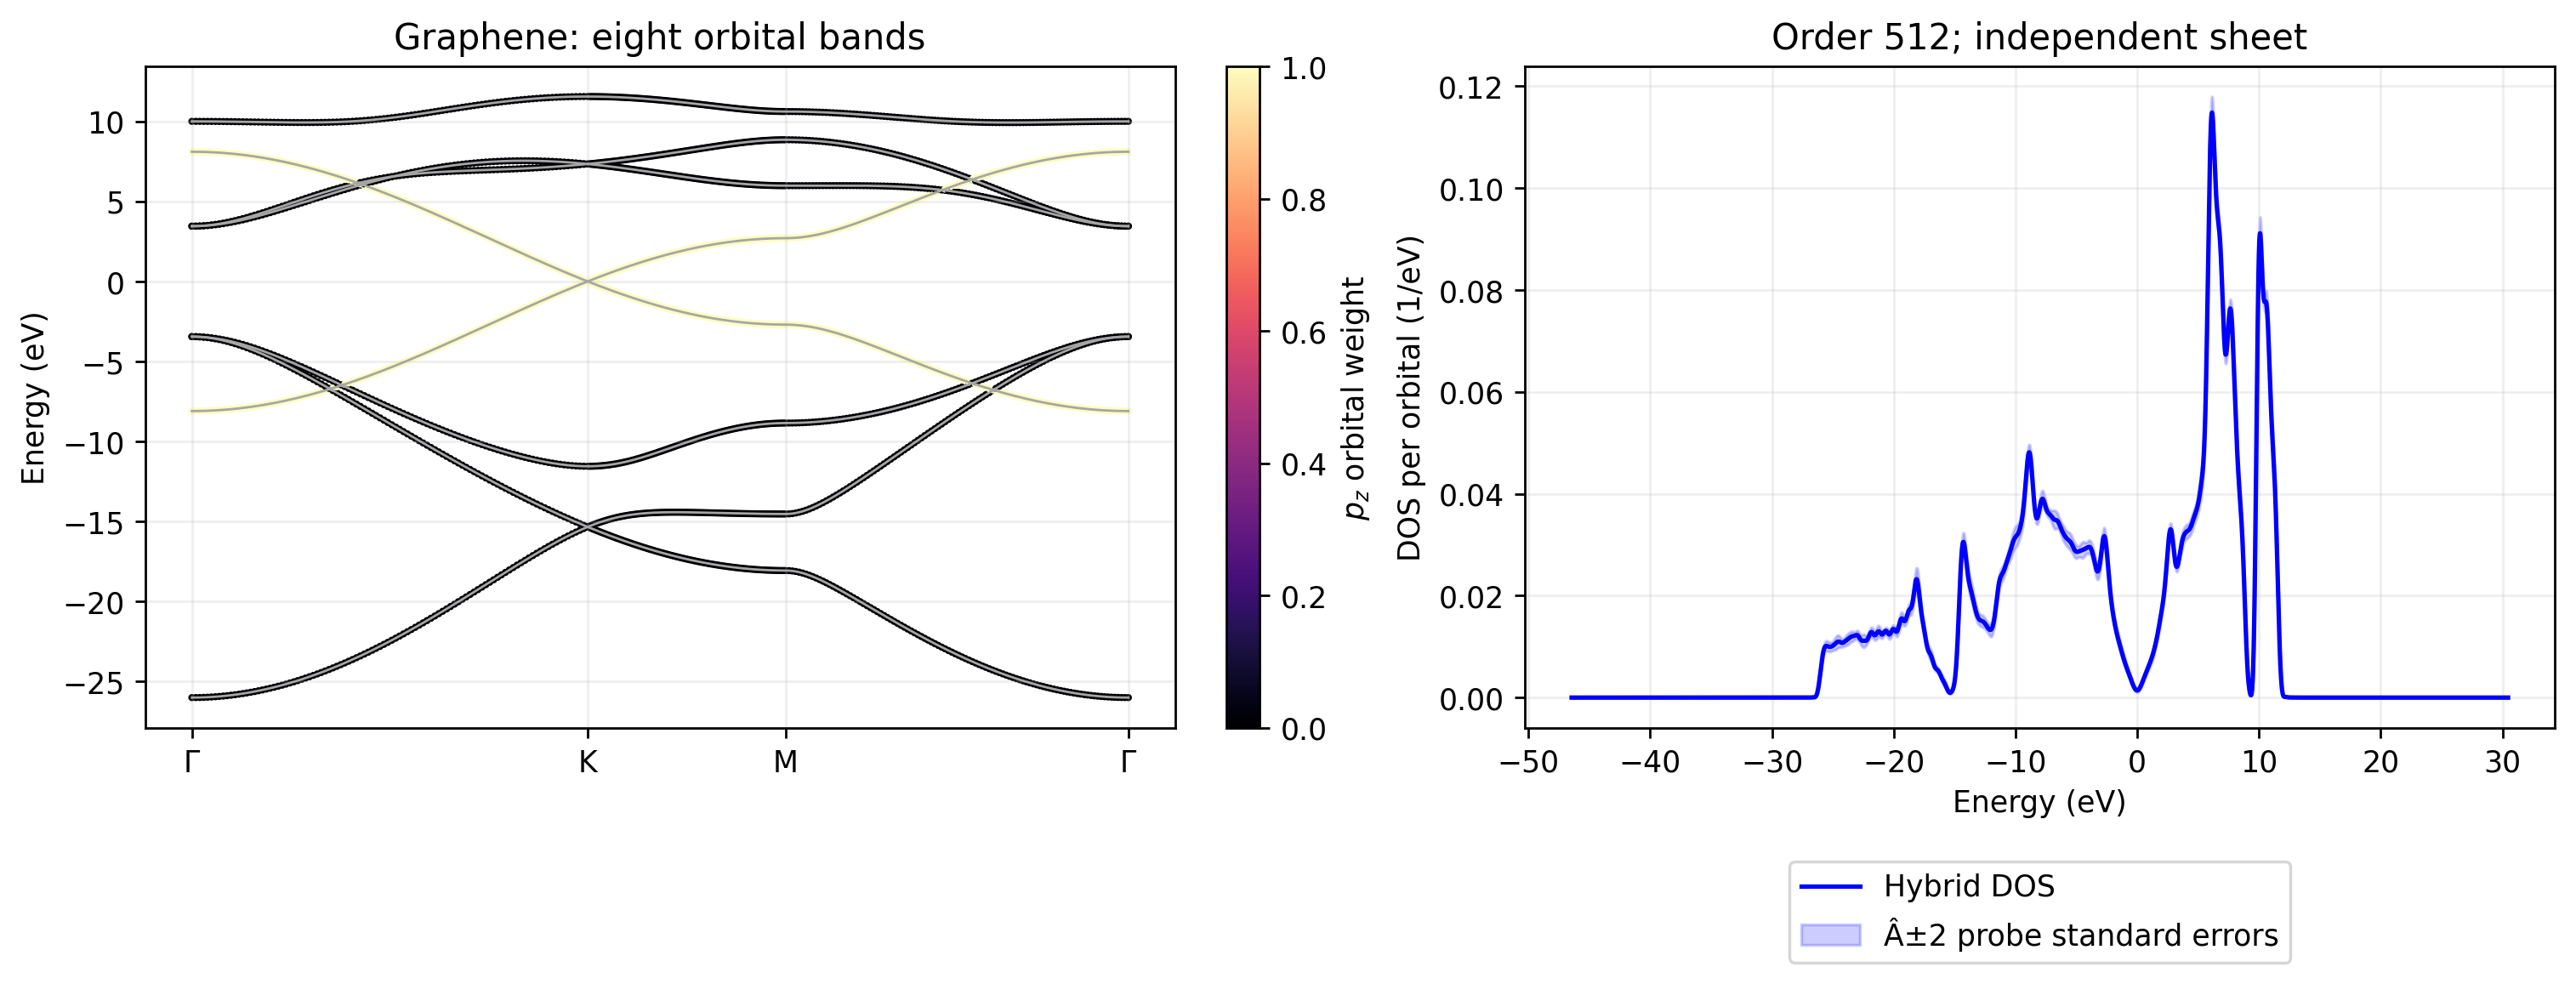

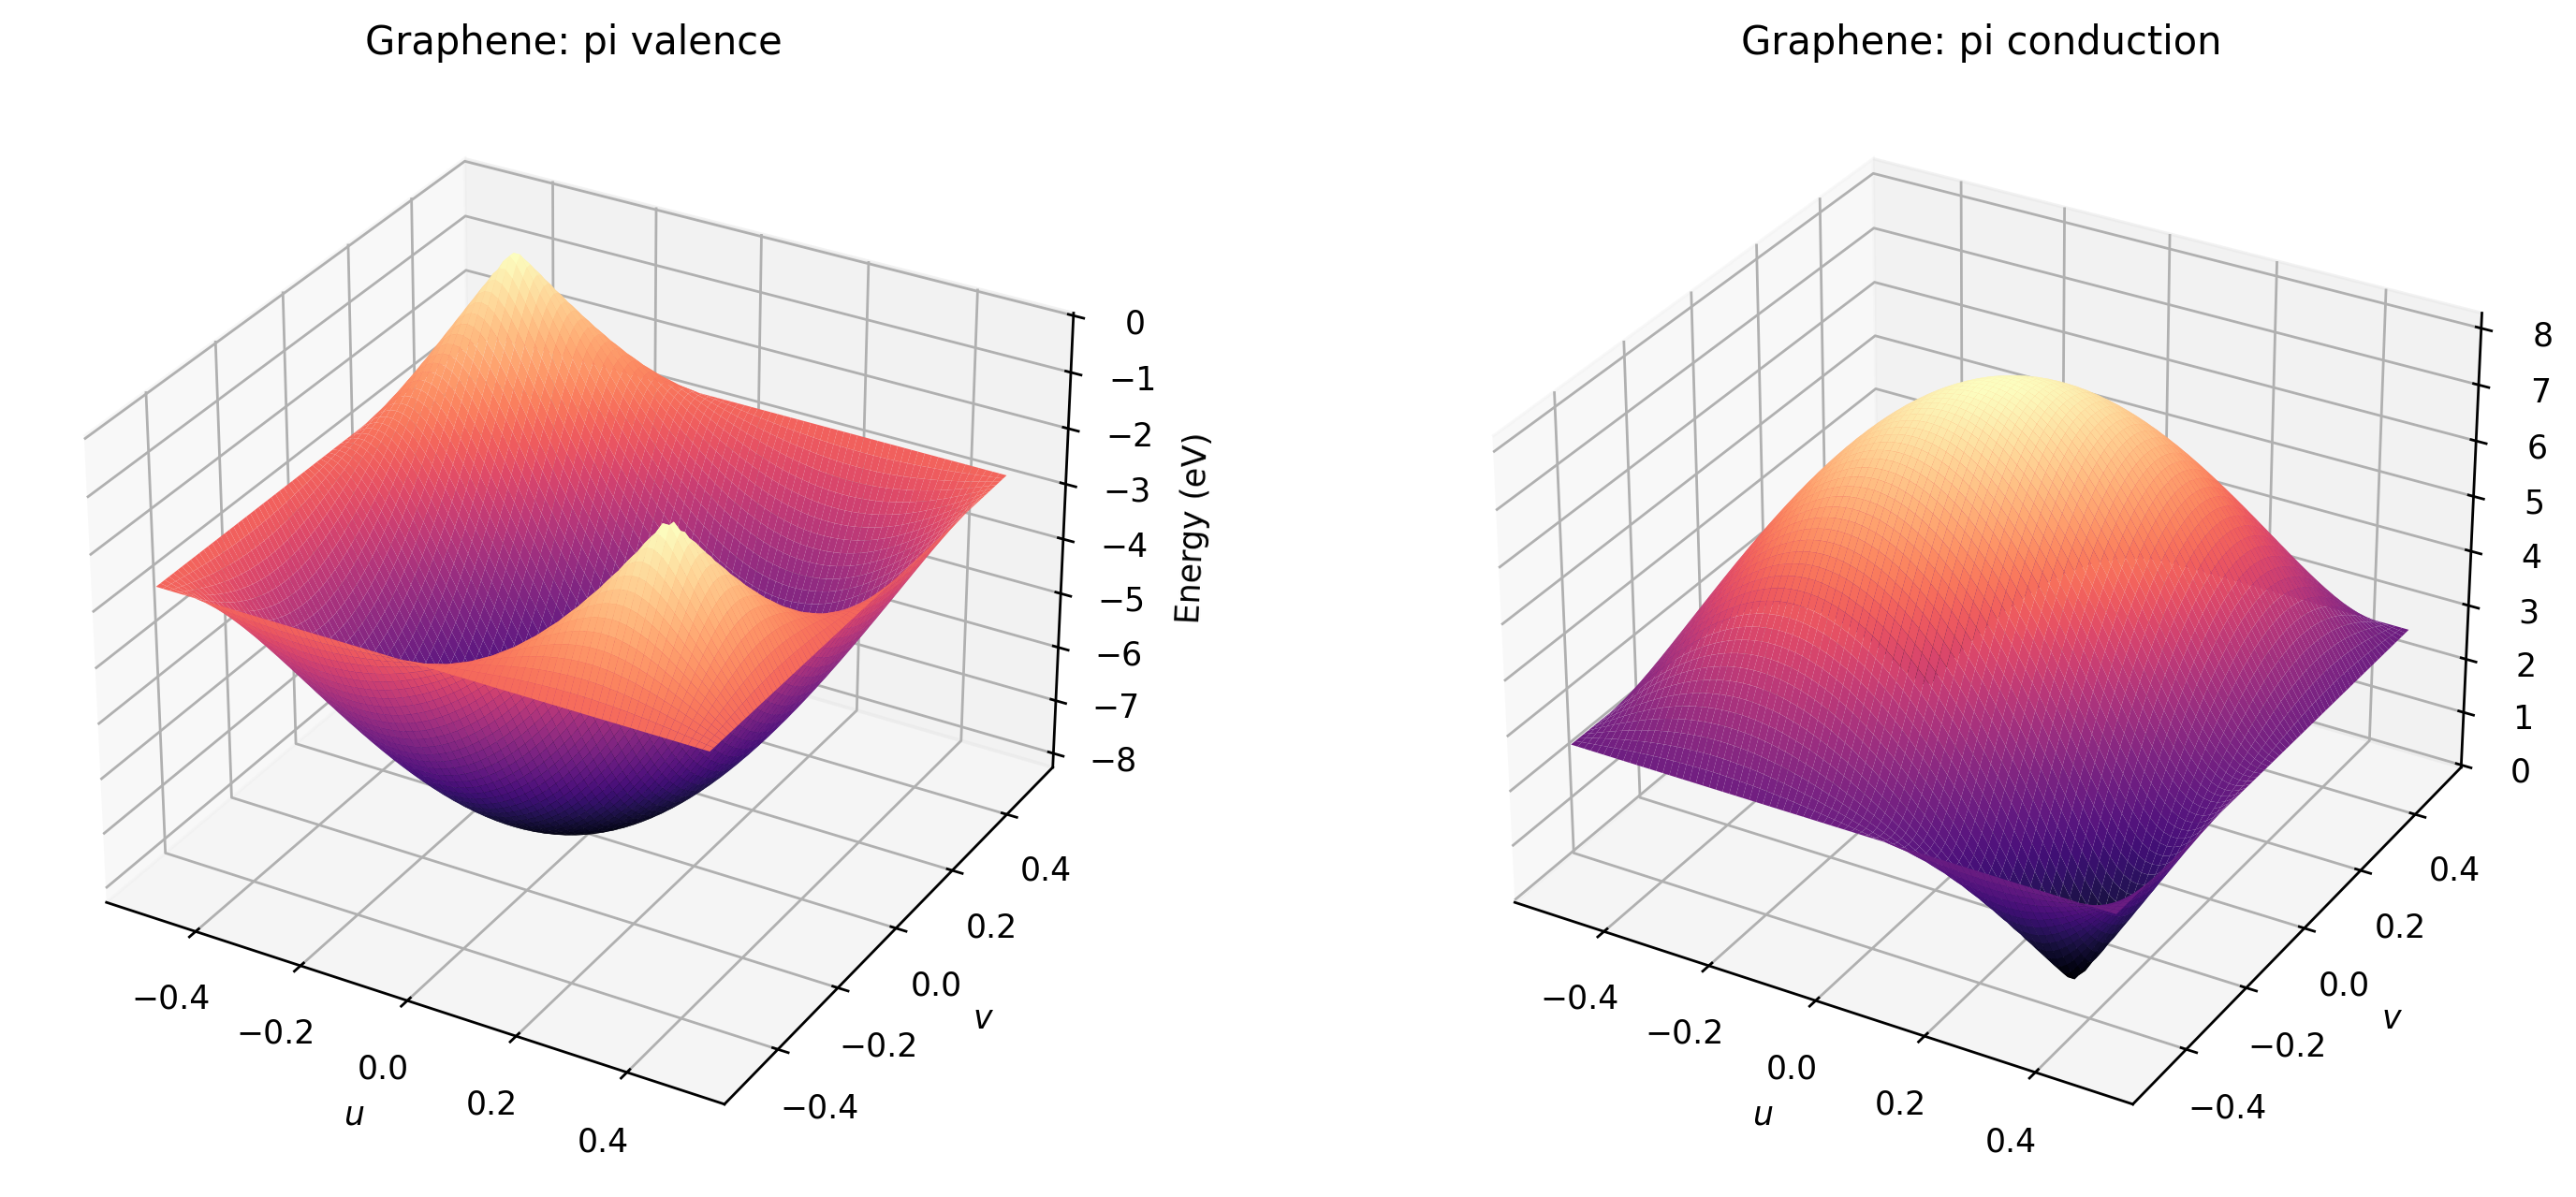

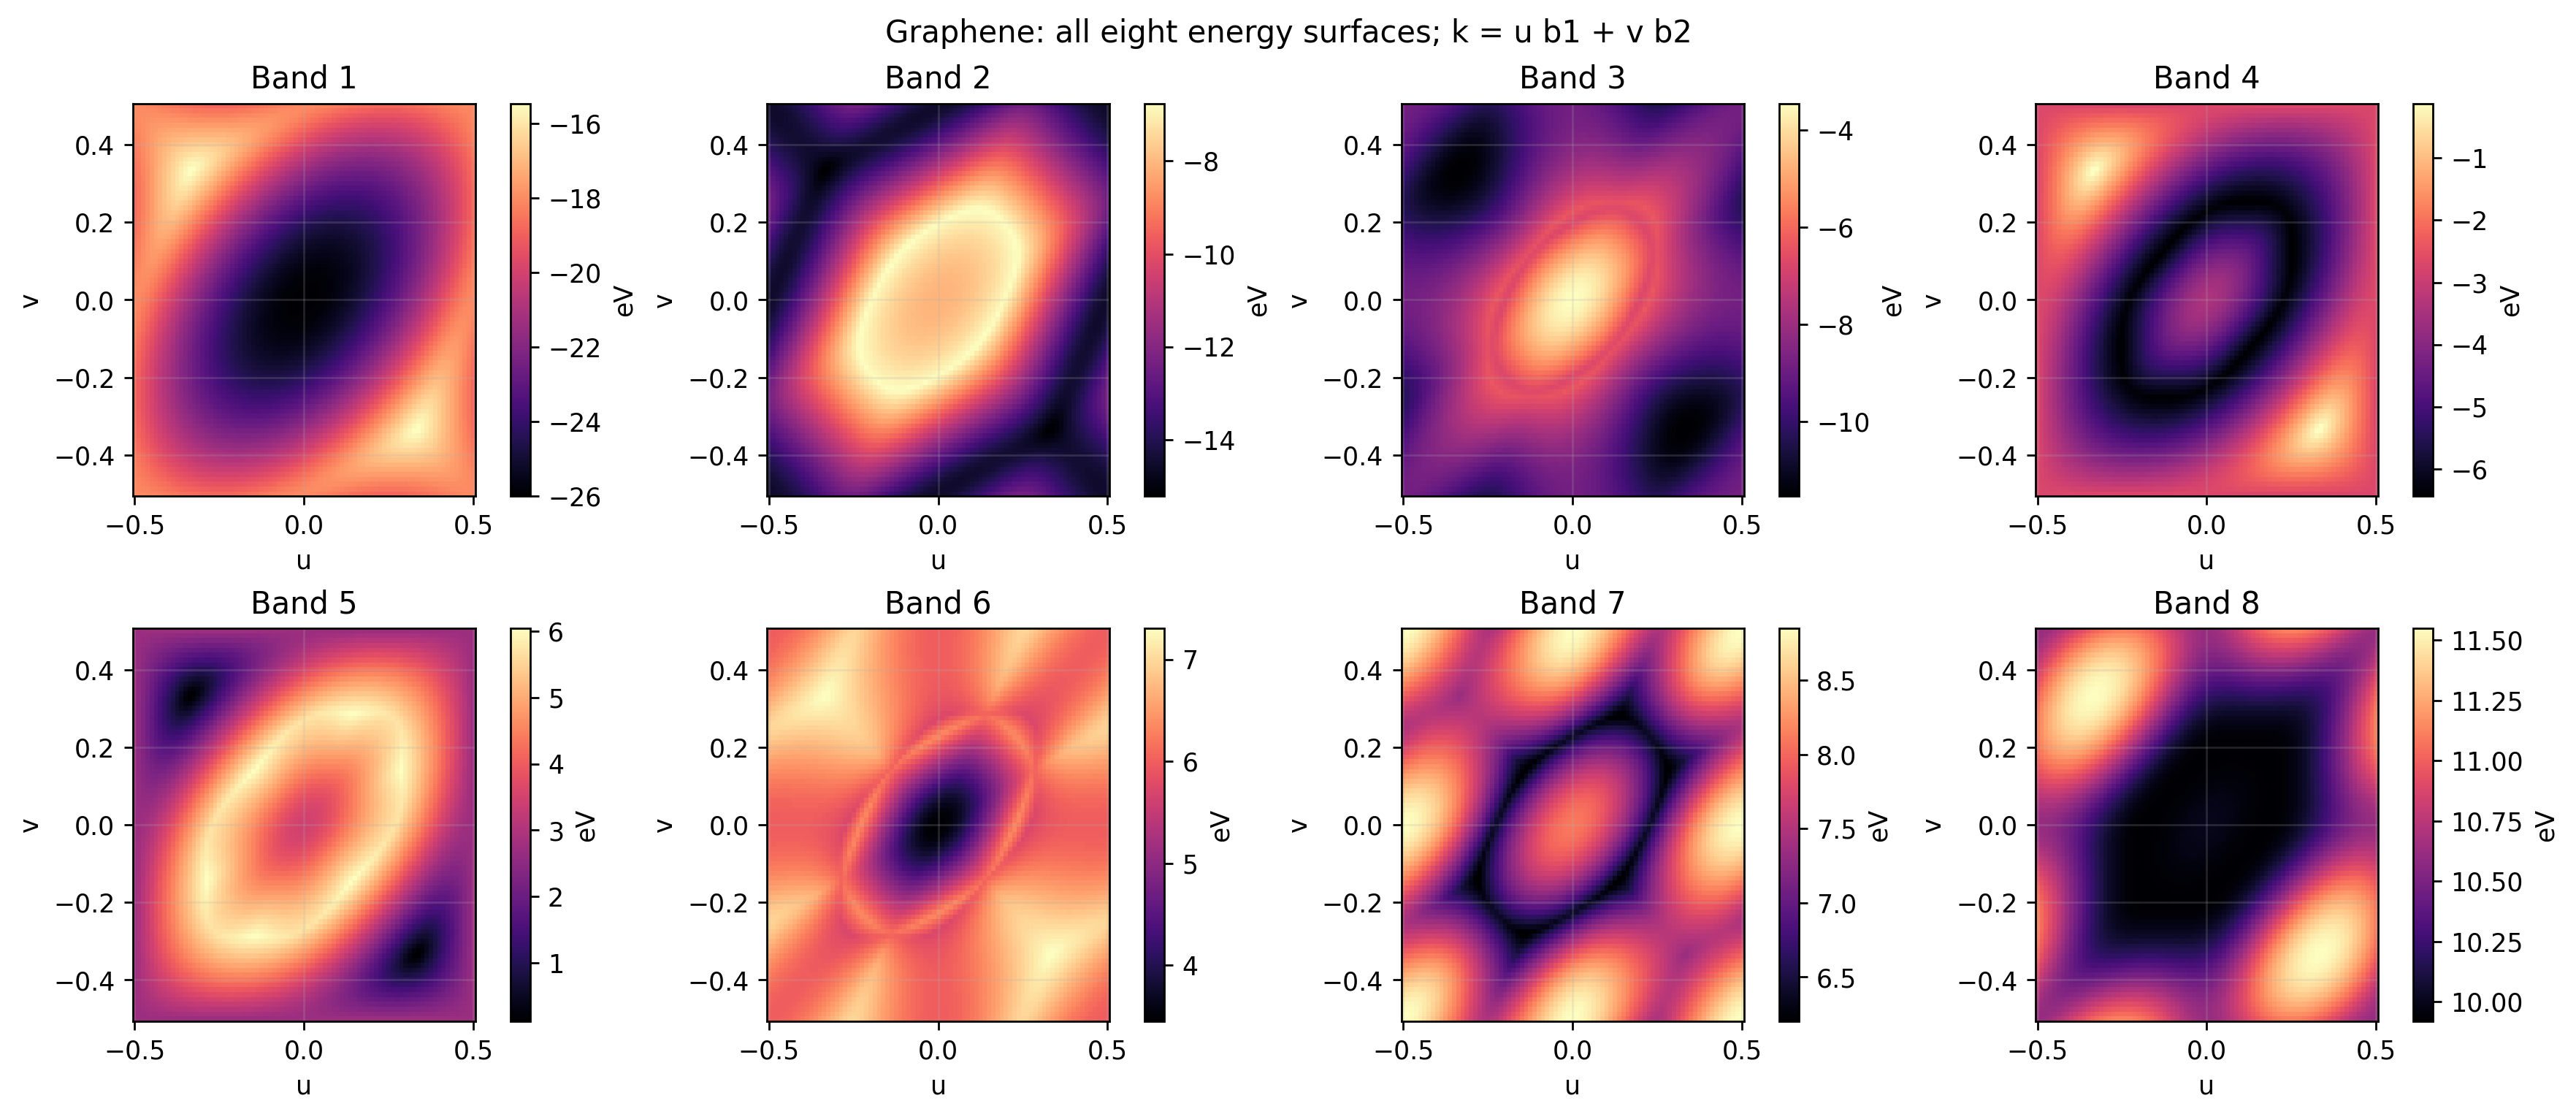

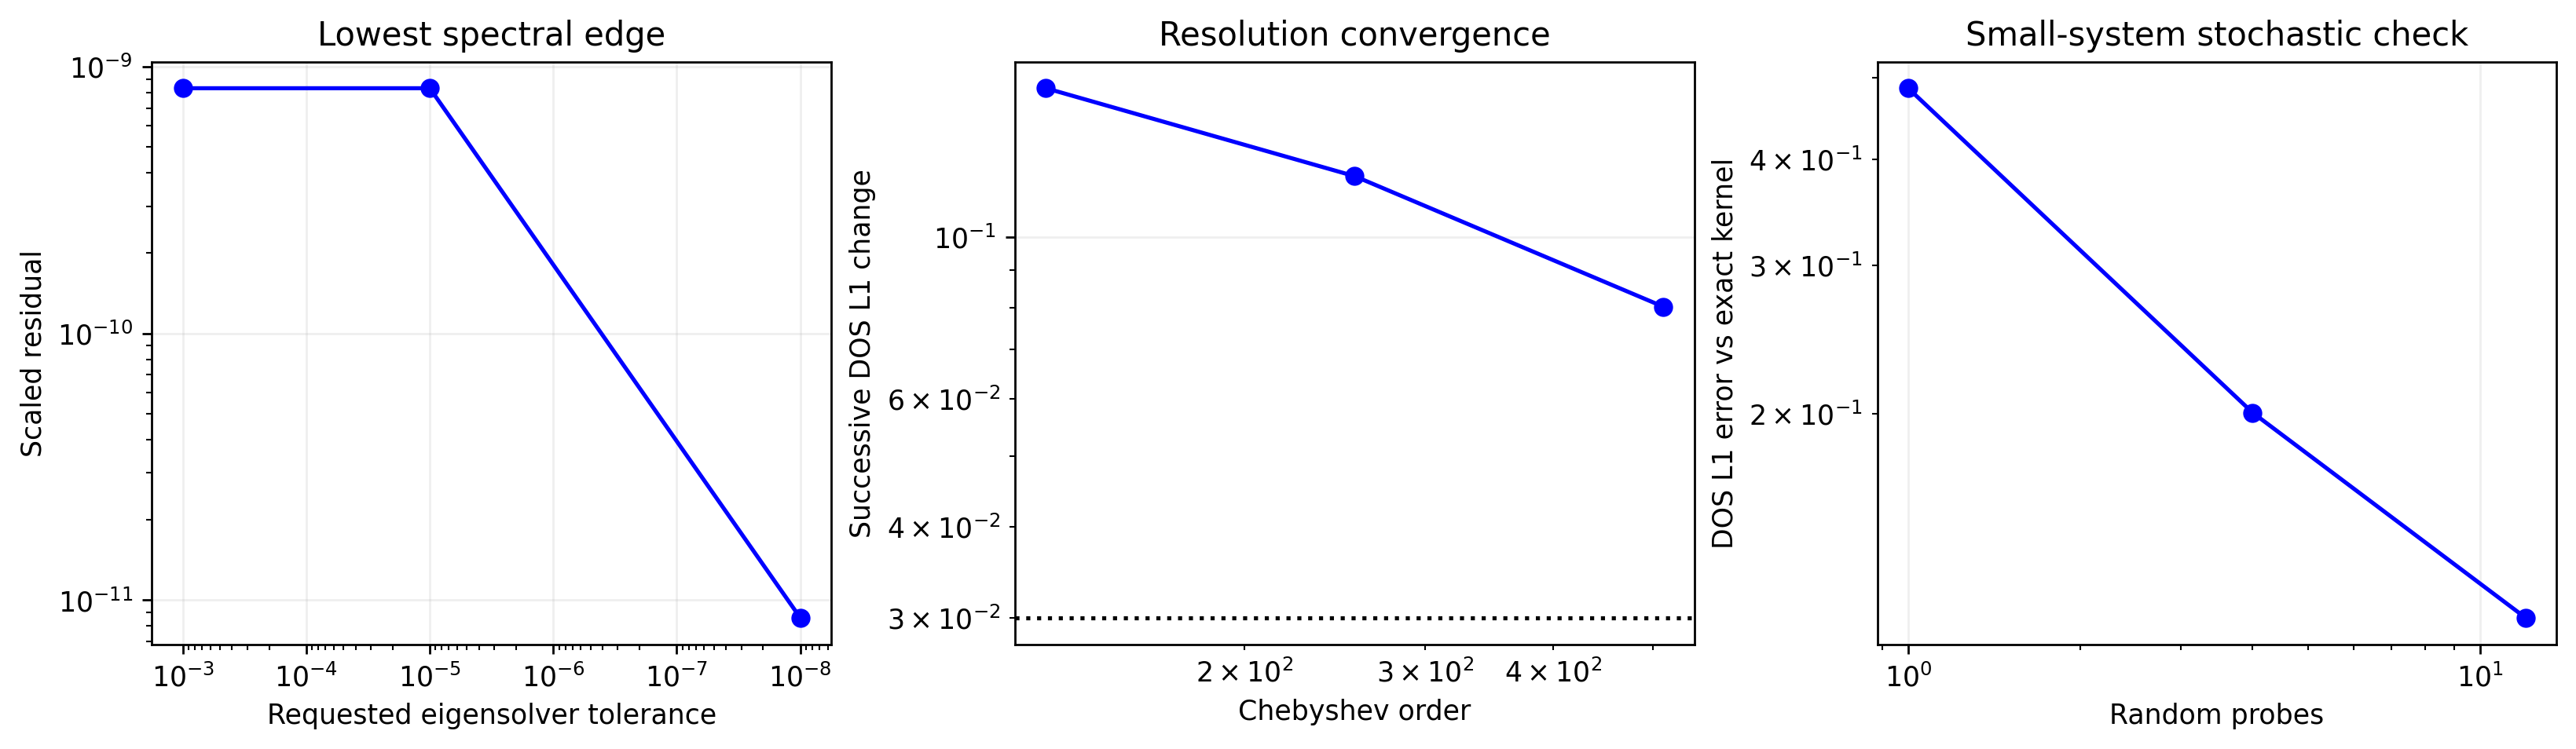


hBN: illustrative orthogonal sp3 model
Bloch/CSR error 3.20e-14 eV; analytic pi error 8.88e-15 eV
float32/float64 maximum moment difference: 1.94e-06
Sparse lowest-edge error: 1.53e-13 eV
Conservative working-memory estimate: 46.2 MiB
Components 5: dense [4, 2, 2]; sparse [7776, 2592]
Selected order 512; DOS area 1.000000
Order criterion: maximum order reached
DOS wall time: 1.49 s; orbitals 10,376; stored entries 77,780
Analytic K-point pi gap: 6.000 eV (model parameter result)
Sampled eight-band half-filling gap: 6.0000 eV


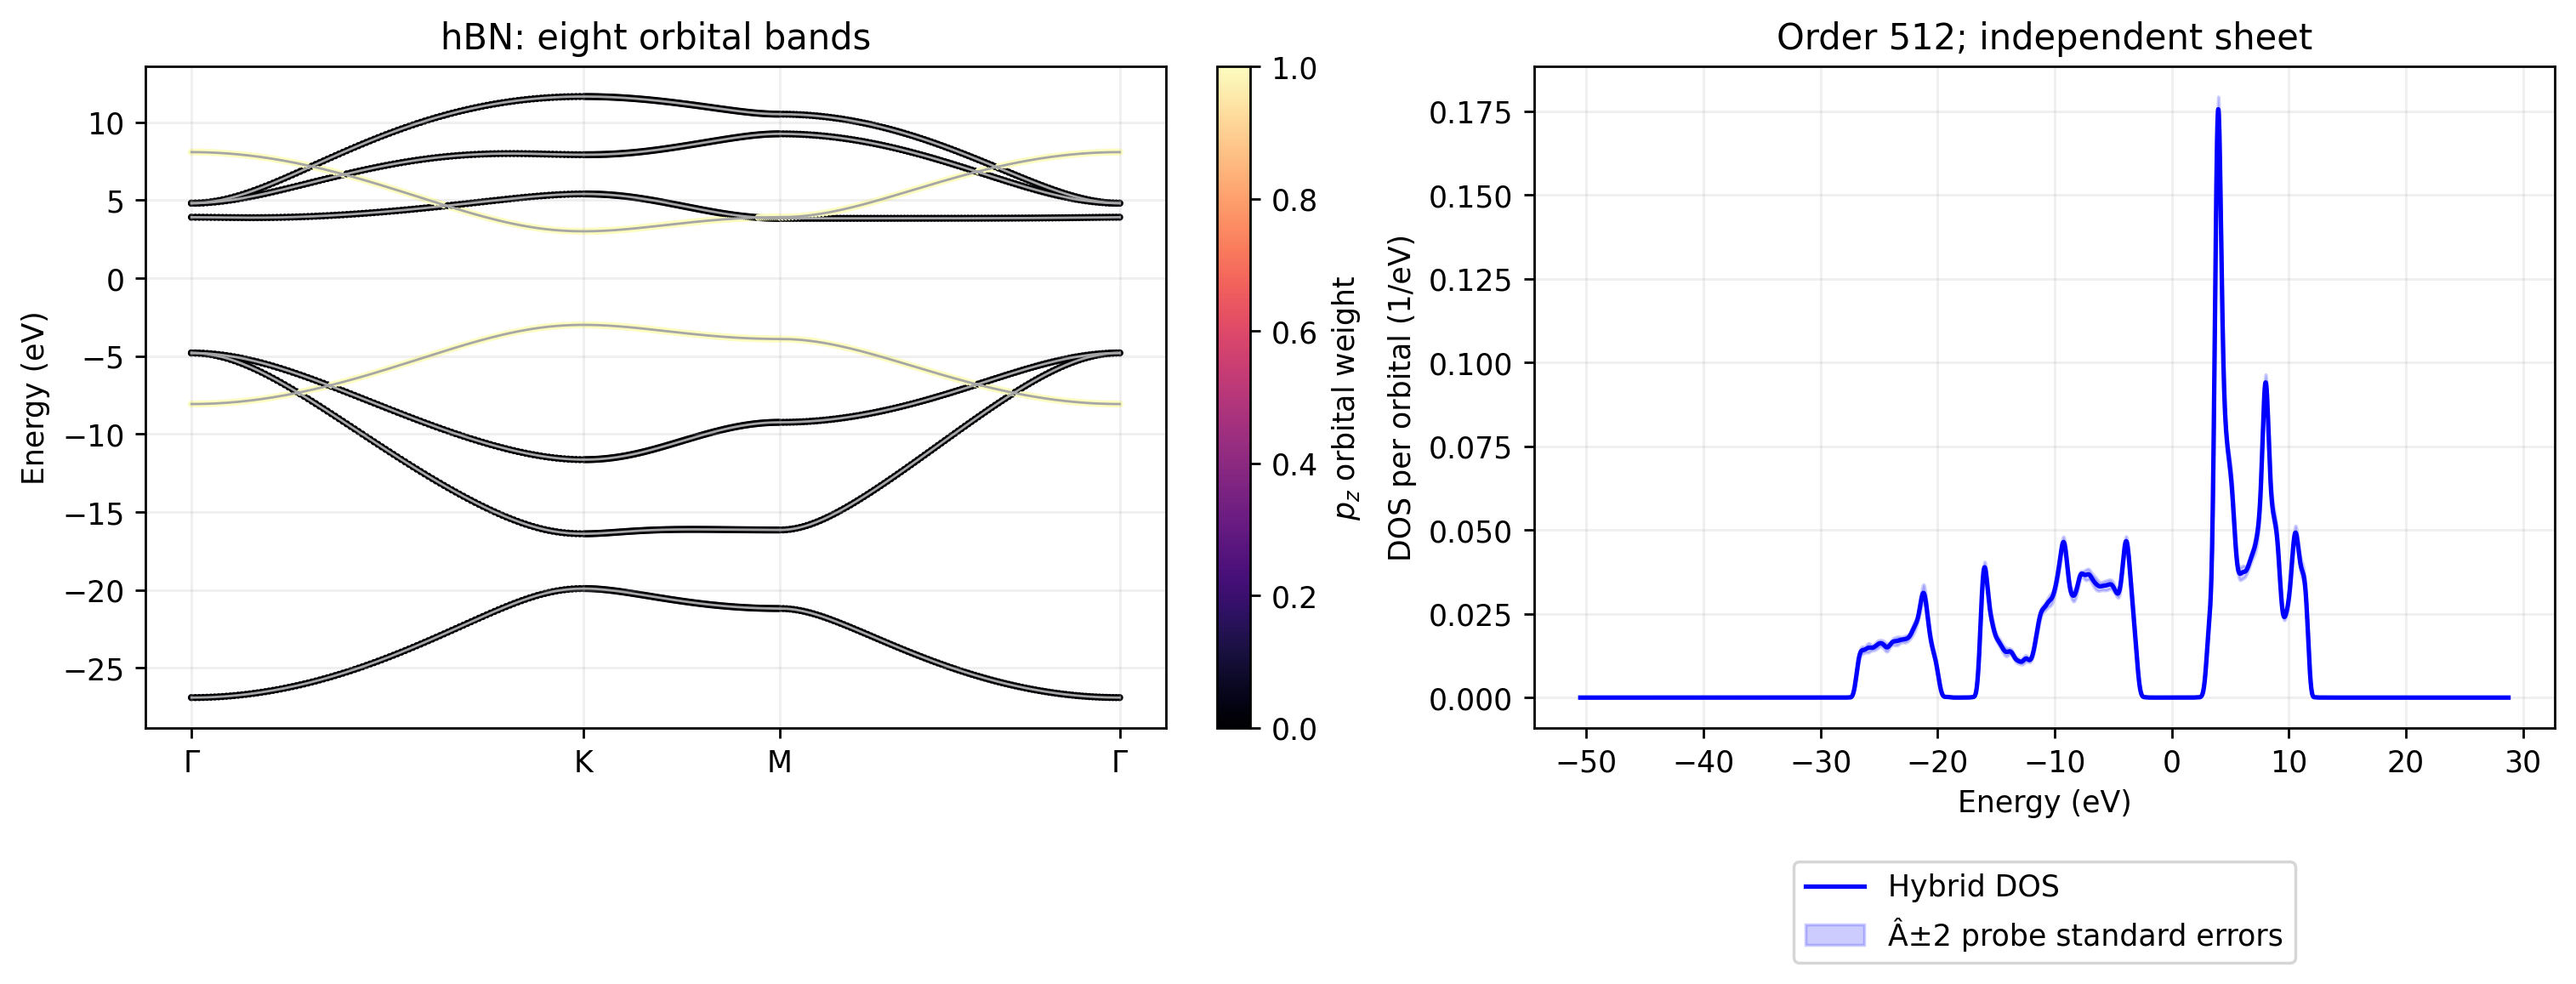

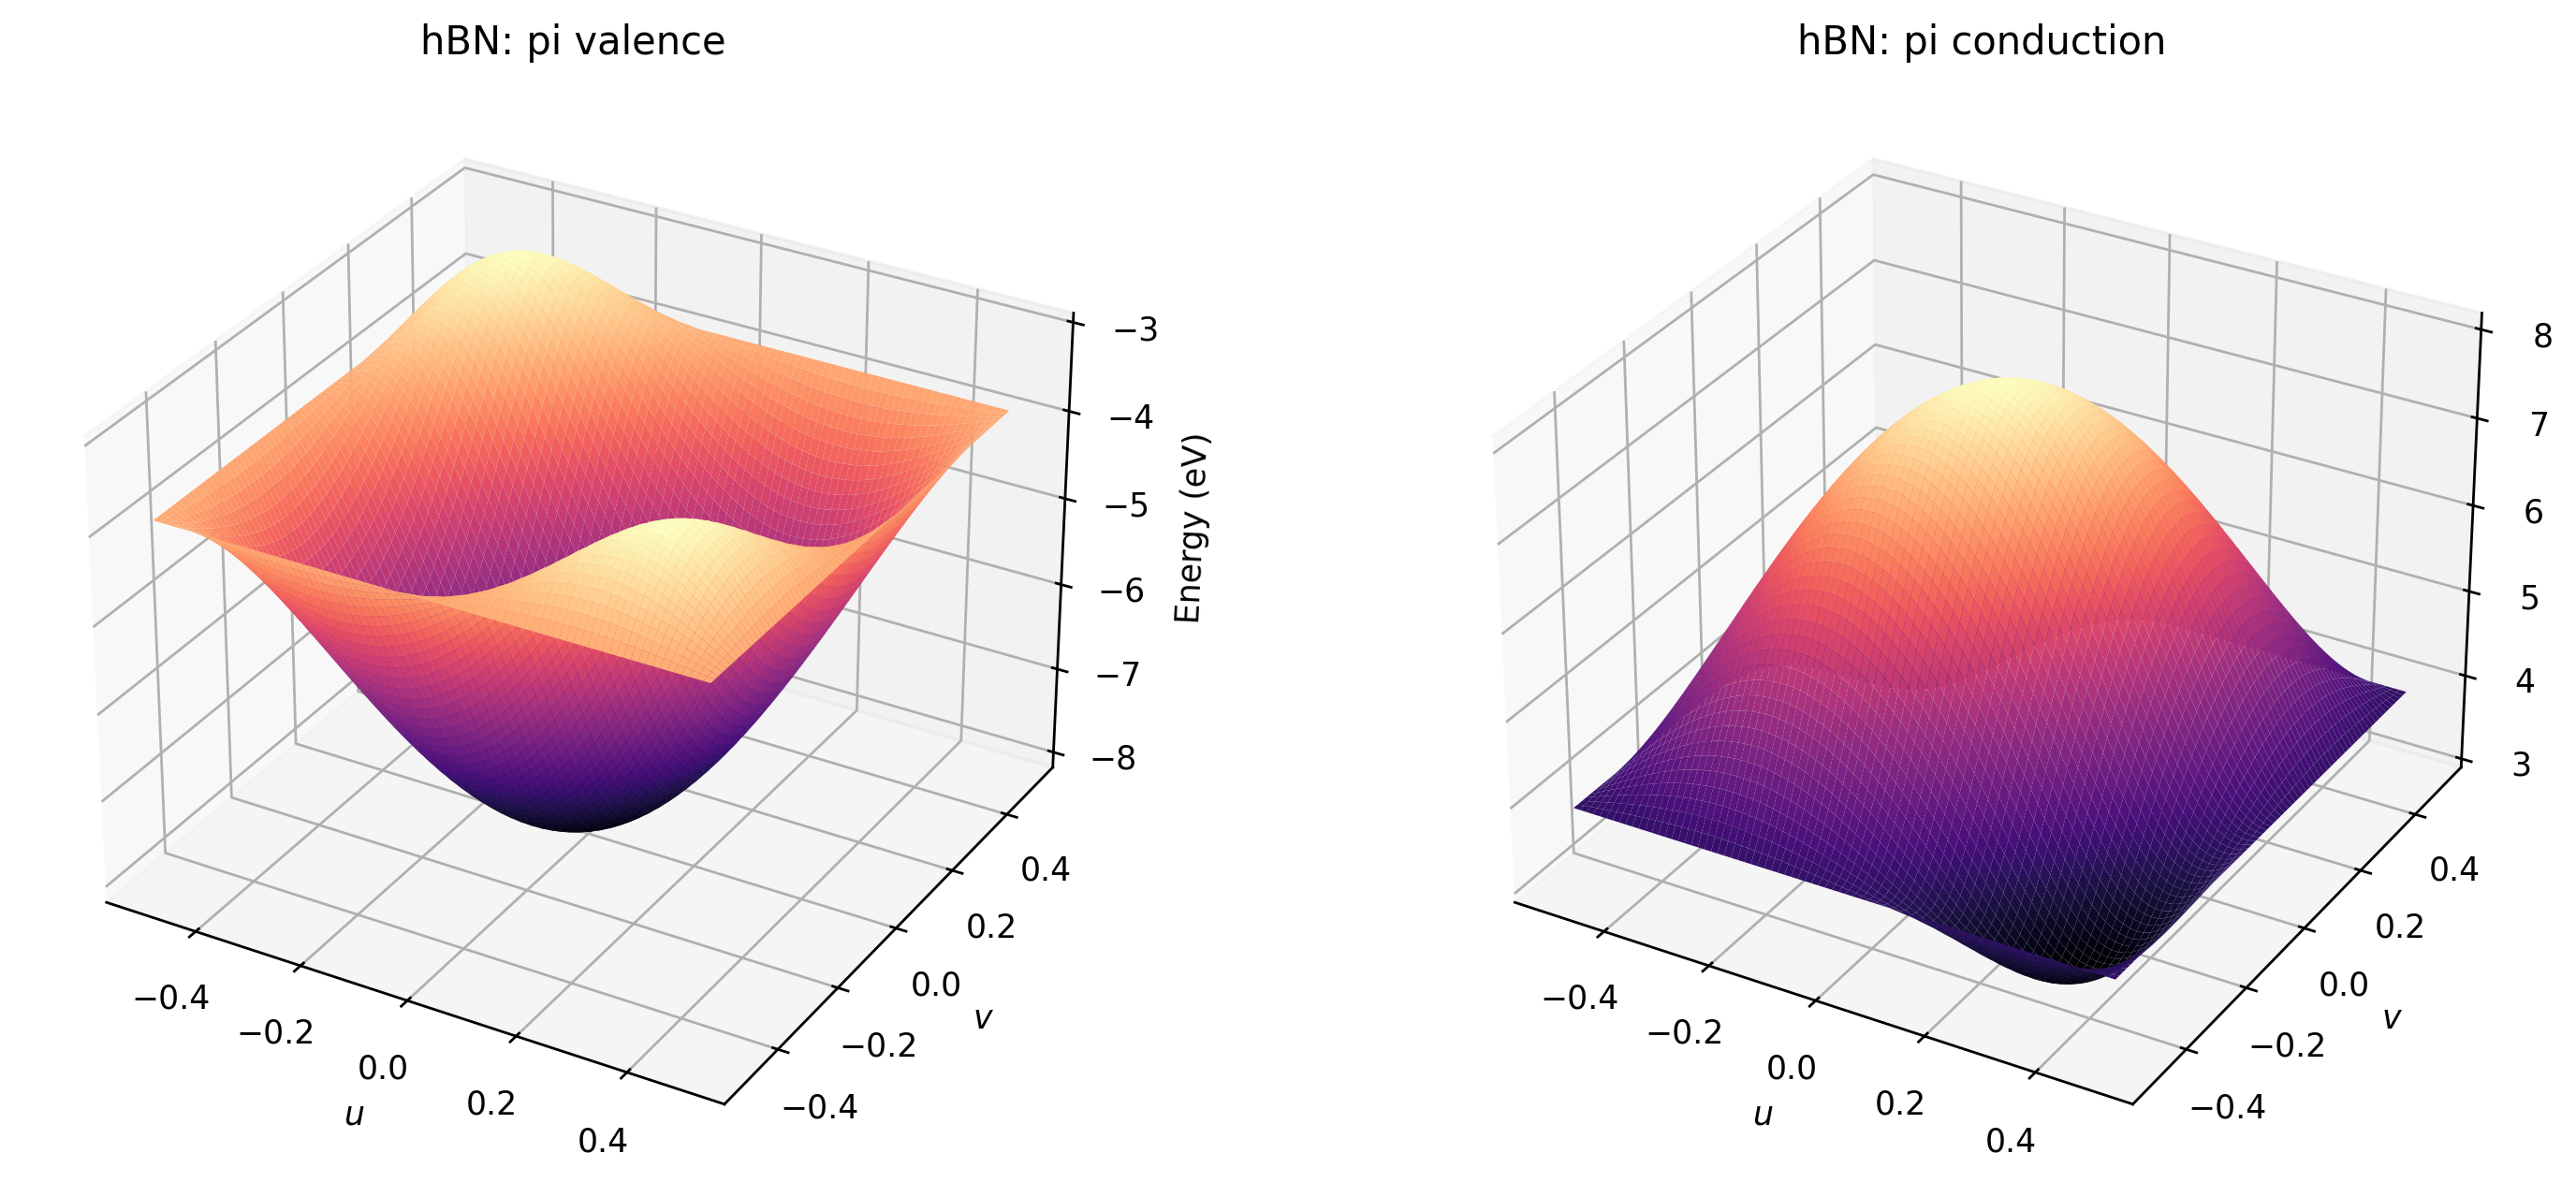

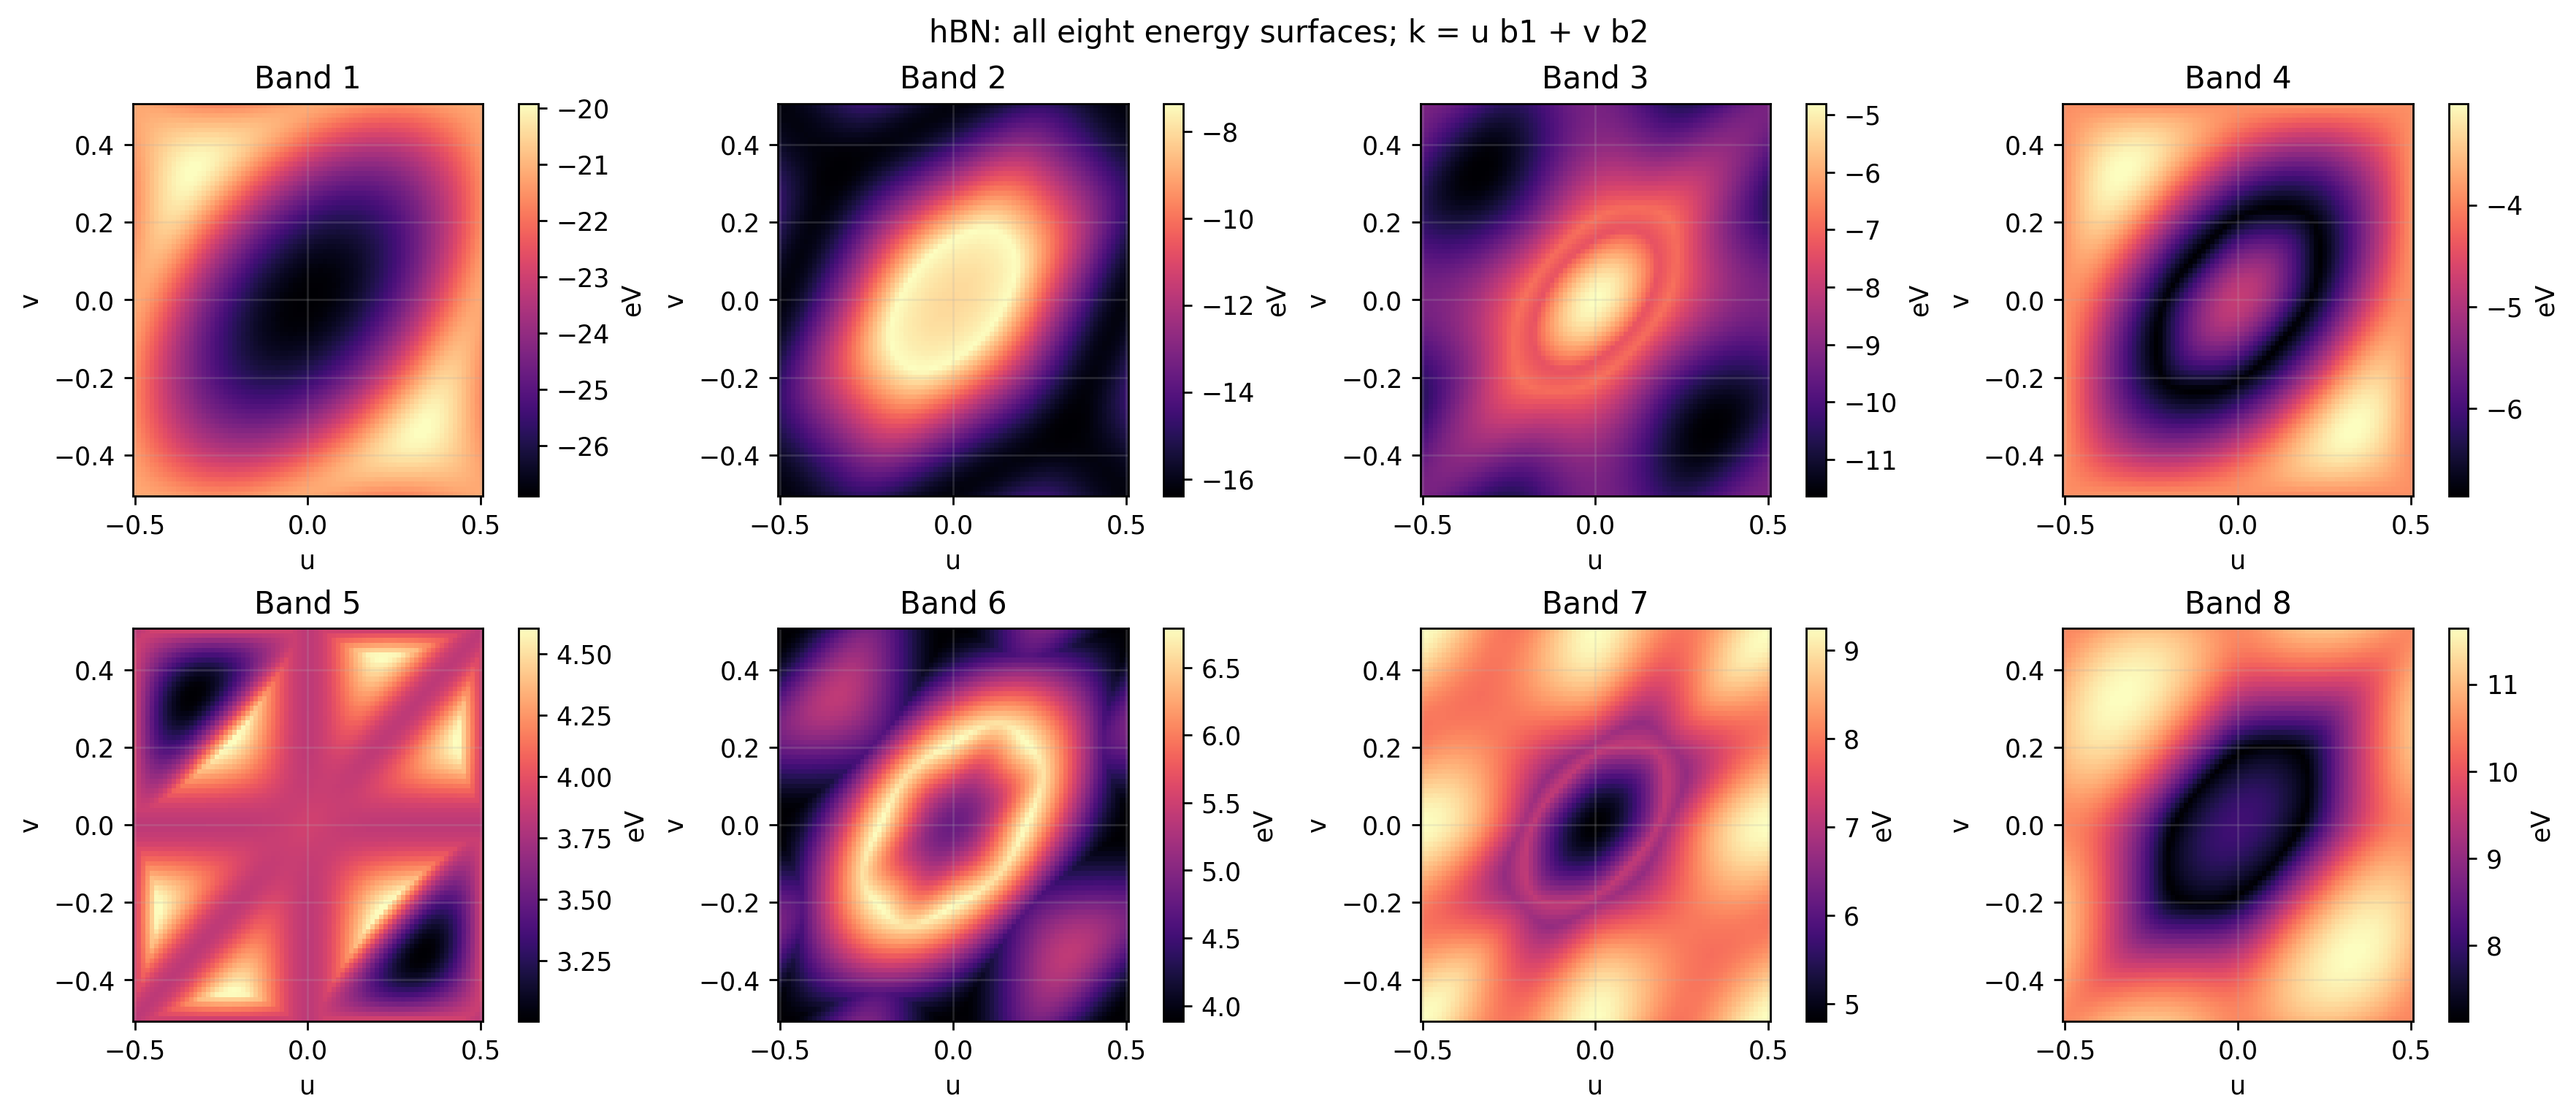

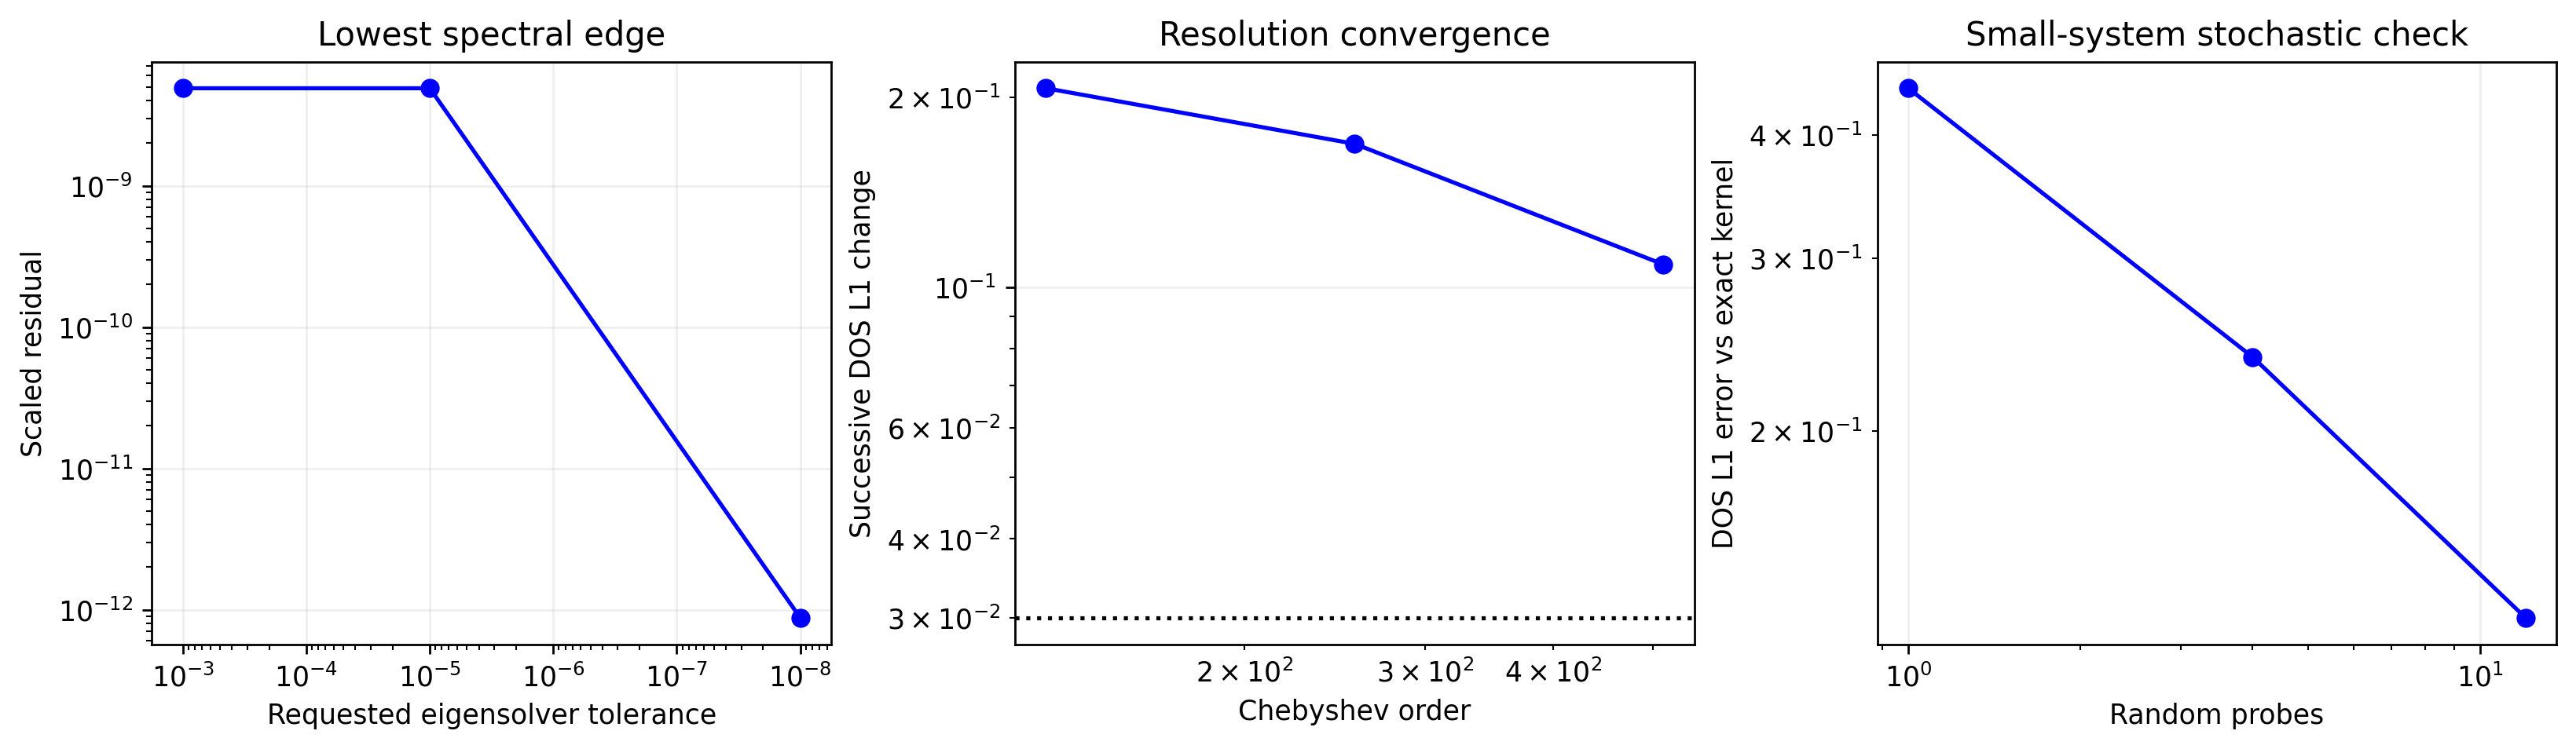

In [2]:
"""Compute graphene and hBN bands, surfaces, and sparse spectral densities.

Eight orthogonal s/px/py/pz orbitals per primitive cell resolve sigma and pi
bands. A CPU graph builder feeds CuPy CSR operations on an NVIDIA GPU.
Parameters are pedagogical, independent-electron examples, without a DFT fit.
Plots are rendered in memory. Set BACKEND='cpu' for a small reference run.
"""

# ----- Control knobs -----
BACKEND = "gpu"
PATH_POINTS = 101
SURFACE_POINTS = 81
K_BATCH = 512
SHEET_NX = 36
SHEET_NY = 36
PERIODIC = True
VACANCY_FRACTION = 0.0
DISORDER_EV = 0.0
ADD_SMALL_ISLAND = True
DENSE_COMPONENT_LIMIT = 128
SPARSE_POLICY = "auto"  # 'auto' or 'always'; dense has a hard size ceiling.
KPM_ORDERS = (64, 128, 256, 512)
KPM_PROBES = 12
KPM_DOS_L1_TOL = 0.03
KPM_PRECISION = "float32"  # Use float64 for an independent precision study.
GPU_MEMORY_FRACTION = 0.35
DENSE_HARD_LIMIT = 1024
EIGENPAIRS = 4
EIGEN_TOLERANCES = (1e-3, 1e-5, 1e-8)
SEED = 42
DPI = 250
RUN_PLOTS = True
MATERIALS = {
    "Graphene": {
        "bond": 1.42, "onsite_a": (-8.0, 0.0, 0.0, 0.0),
        "onsite_b": (-8.0, 0.0, 0.0, 0.0),
        "ss": -6.0, "sp": 5.0, "ps": 5.0, "pp_sigma": 5.0,
        "pp_pi": -2.7,
    },
    "hBN": {
        "bond": 1.45, "onsite_a": (-8.0, 3.0, 3.0, 3.0),
        "onsite_b": (-15.0, -3.0, -3.0, -3.0),
        "ss": -5.0, "sp": 5.0, "ps": 5.0, "pp_sigma": 5.0,
        "pp_pi": -2.5,
    },
}

import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sps
from scipy.sparse.csgraph import connected_components
from scipy.integrate import trapezoid


def initialize_backend():
    """Select a backend and exercise the numerical operations used below."""
    global xp, sparse, sparse_eigsh, linalg_errstate
    if BACKEND == "gpu":
        from cupyx import errstate
        import cupy as cp
        import cupyx.scipy.sparse as cps
        from cupyx.scipy.sparse.linalg import eigsh

        if cp.cuda.runtime.getDeviceCount() < 1:
            raise RuntimeError("Select a Colab GPU runtime, then run again.")
        xp, sparse, sparse_eigsh = cp, cps, eigsh
        linalg_errstate = errstate
        props = cp.cuda.runtime.getDeviceProperties(0)
        name = props["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU: {name}; CuPy {cp.__version__}")
        print(f"CUDA runtime: {cp.cuda.runtime.runtimeGetVersion()}")
        test = cp.asarray([[2.0, 0.2], [0.2, 1.0]])
        cp.linalg.eigh(test)
        cps.csr_matrix(test) @ cp.ones((2, 2))
        cp.cuda.Stream.null.synchronize()
        if "L4" not in name:
            print("This GPU is usable; select L4 for the requested hardware.")
    elif BACKEND == "cpu":
        from scipy.sparse.linalg import eigsh

        xp, sparse, sparse_eigsh = np, sps, eigsh
        print("CPU reference backend; GPU performance is unmeasured.")
    else:
        raise ValueError("BACKEND must be 'gpu' or 'cpu'.")
    plt.rcParams.update({"figure.dpi": DPI, "savefig.dpi": DPI,
                         "font.size": 10, "axes.grid": True,
                         "grid.alpha": 0.2})


def host(array):
    """Return a NumPy array from the selected backend."""
    return xp.asnumpy(array) if BACKEND == "gpu" else np.asarray(array)


def synchronize():
    """Complete GPU work before recording a wall-clock time."""
    if BACKEND == "gpu":
        xp.cuda.Stream.null.synchronize()


def geometry(material):
    """Return A-to-B bonds, primitive vectors, and reciprocal row vectors."""
    d = material["bond"]
    bonds = d * np.array([[0, 1, 0], [-np.sqrt(3) / 2, -0.5, 0],
                          [np.sqrt(3) / 2, -0.5, 0]])
    a = np.array([bonds[0, :2] - bonds[1, :2],
                  bonds[0, :2] - bonds[2, :2]])
    b = 2 * np.pi * np.linalg.inv(a).T
    return bonds, a, b


def hopping_blocks(material):
    """Build Slater-Koster A-to-B blocks with odd s-p parity."""
    bonds, _, _ = geometry(material)
    blocks = []
    for bond in bonds:
        direction = bond / np.linalg.norm(bond)
        block = np.zeros((4, 4))
        block[0, 0] = material["ss"]
        block[0, 1:] = material["sp"] * direction
        block[1:, 0] = -material["ps"] * direction
        block[1:, 1:] = (
            material["pp_pi"] * np.eye(3)
            + (material["pp_sigma"] - material["pp_pi"])
            * np.outer(direction, direction)
        )
        blocks.append(block)
    return np.array(blocks)


def bloch_bands(k_points, material, return_pi=False):
    """Diagonalize bounded batches of eight-by-eight Bloch Hamiltonians."""
    bonds, _, _ = geometry(material)
    blocks = xp.asarray(hopping_blocks(material))
    onsite = xp.asarray(material["onsite_a"] + material["onsite_b"])
    energies, weights = [], []
    for start in range(0, len(k_points), K_BATCH):
        k = xp.asarray(k_points[start:start + K_BATCH])
        phase = xp.exp(1j * (k @ xp.asarray(bonds[:, :2]).T))
        coupling = xp.einsum("kd,dij->kij", phase, blocks)
        h = xp.zeros((len(k), 8, 8), dtype=xp.complex128)
        indices = xp.arange(8)
        h[:, indices, indices] = onsite
        h[:, :4, 4:] = coupling
        h[:, 4:, :4] = coupling.conj().transpose(0, 2, 1)
        with linalg_errstate(linalg="raise") if BACKEND == "gpu" else np.errstate():
            values, vectors = xp.linalg.eigh(h)
        energies.append(host(values))
        if return_pi:
            weights.append(host(xp.sum(xp.abs(vectors[:, [3, 7], :])**2,
                                       axis=1)))
    values = np.concatenate(energies)
    return (values, np.concatenate(weights)) if return_pi else values


def pi_reference(k_points, material):
    """Compute the closed-form two-band pz spectrum in the same gauge."""
    bonds, _, _ = geometry(material)
    f = np.exp(1j * (k_points @ bonds[:, :2].T)).sum(axis=1)
    ea, eb = material["onsite_a"][3], material["onsite_b"][3]
    split = np.sqrt(((ea - eb) / 2)**2 + abs(material["pp_pi"] * f)**2)
    return np.column_stack(((ea + eb) / 2 - split, (ea + eb) / 2 + split))


def build_sheet(material, nx, ny, periodic=True, vacancy=0.0,
                disorder=0.0, island=False):
    """Assemble orbital CSR from O(N) honeycomb edges on the CPU.

    A(i,j) connects to B(i,j), B(i-1,j), and B(i,j-1).
    A separate dimer can exercise the exact small-component branch.
    """
    if min(nx, ny) < 3 or not 0 <= vacancy < 1:
        raise ValueError("Use nx,ny >= 3 and vacancy in [0,1).")
    rng = np.random.default_rng(SEED)
    cells = np.arange(nx * ny).reshape(nx, ny)
    rows, cols, data = [], [], []
    blocks = hopping_blocks(material)
    for shift, block in zip(((0, 0), (-1, 0), (0, -1)), blocks):
        i, j = np.indices((nx, ny))
        ni, nj = i + shift[0], j + shift[1]
        keep = np.ones_like(i, dtype=bool) if periodic else (
            (ni >= 0) & (ni < nx) & (nj >= 0) & (nj < ny))
        a_ids = 2 * cells[keep]
        b_ids = 2 * cells[ni[keep] % nx, nj[keep] % ny] + 1
        for p, q in zip(*np.nonzero(block)):
            r, c = 4 * a_ids + p, 4 * b_ids + q
            rows.extend((r, c))
            cols.extend((c, r))
            data.extend((np.full(len(r), block[p, q]),
                         np.full(len(r), block[p, q])))
    n_atoms = 2 * nx * ny
    onsite = np.tile(material["onsite_a"] + material["onsite_b"], nx * ny)
    onsite += np.repeat(rng.uniform(-disorder / 2, disorder / 2, n_atoms), 4)
    rows.append(np.arange(4 * n_atoms))
    cols.append(np.arange(4 * n_atoms))
    data.append(onsite)
    h = sps.coo_matrix((np.concatenate(data),
                       (np.concatenate(rows), np.concatenate(cols))),
                      shape=(4 * n_atoms, 4 * n_atoms)).tocsr()
    keep_atoms = rng.random(n_atoms) >= vacancy
    if keep_atoms.sum() == 0:
        raise ValueError("Vacancies removed all atoms.")
    keep_orbitals = np.flatnonzero(np.repeat(keep_atoms, 4))
    h = h[keep_orbitals][:, keep_orbitals]
    if island:
        dimer = np.diag(material["onsite_a"] + material["onsite_b"])
        dimer[:4, 4:] = blocks[0]
        dimer[4:, :4] = blocks[0].T
        h = sps.block_diag((h, sps.csr_matrix(dimer)), format="csr")
    h.eliminate_zeros()
    h.sort_indices()
    return h


def scaling(h):
    """Use Gershgorin bounds with a 5 percent Chebyshev safety margin."""
    diagonal = h.diagonal()
    radius = np.asarray(abs(h).sum(axis=1)).ravel() - abs(diagonal)
    low, high = np.min(diagonal - radius), np.max(diagonal + radius)
    center = (low + high) / 2
    scale = max((high - low) / 2 * 1.05, 1e-6)
    return scale, center


def exact_moments(values, scale, center, order):
    """Return normalized Chebyshev trace moments from eigenvalues."""
    x = (values - center) / scale
    t0, t1 = np.ones_like(x), x.copy()
    moments = np.empty(order)
    moments[0], moments[1] = 1.0, t1.mean()
    for m in range(2, order):
        t0, t1 = t1, 2 * x * t1 - t0
        moments[m] = t1.mean()
    return moments


def stochastic_moments(h, scale, center, order, probes, precision):
    """Evaluate GPU CSR Chebyshev recurrences using fixed random probes."""
    dtype = np.dtype(precision)
    scaled = (h - center * sps.eye(h.shape[0], format="csr")) / scale
    matrix = sparse.csr_matrix(scaled.astype(dtype))
    rng = np.random.default_rng(SEED)
    signs = 2 * rng.integers(0, 2, size=(h.shape[0], probes)) - 1
    z = xp.asarray(signs, dtype=dtype)
    t0, t1 = z.copy(), matrix @ z
    moments = xp.empty((order, probes), dtype=xp.float64)
    moments[0] = 1.0
    moments[1] = xp.sum(z * t1, axis=0, dtype=xp.float64) / h.shape[0]
    for m in range(2, order):
        t0, t1 = t1, 2 * (matrix @ t1) - t0
        moments[m] = xp.sum(z * t1, axis=0, dtype=xp.float64) / h.shape[0]
    result = host(moments)
    if not np.isfinite(result).all() or np.max(abs(result)) > 1.01:
        raise FloatingPointError("Chebyshev recurrence failed its bound check.")
    return result


def density(moments, scale, center, energies):
    """Reconstruct Jackson-damped DOS per orbital per eV."""
    m = np.arange(len(moments))
    order = len(moments)
    angle = np.pi / (order + 1)
    jackson = ((order - m + 1) * np.cos(m * angle)
               + np.sin(m * angle) / np.tan(angle)) / (order + 1)
    x = (energies - center) / scale
    result = np.zeros_like(x)
    inside = abs(x) < 1
    theta = np.arccos(x[inside])
    coefficients = jackson * moments
    coefficients = coefficients.copy()
    coefficients[1:] *= 2
    result[inside] = (coefficients @ np.cos(np.outer(m, theta))) / (
        np.pi * scale * np.sqrt(1 - x[inside]**2))
    return result


def hybrid_dos(h):
    """Combine exact small orbital components and stochastic large blocks.

    Order convergence is evaluated at a common energy grid. A separate
    probe standard error reports stochastic uncertainty at the chosen order.
    """
    count, labels = connected_components(h, directed=False)
    scale, center = scaling(h)
    order = max(KPM_ORDERS)
    energies = center + scale * np.linspace(-0.999, 0.999, 4097)
    dense_sizes, sparse_sizes = [], []
    permutation = np.argsort(labels)
    groups = np.split(permutation, np.cumsum(np.bincount(labels))[:-1])
    components = []
    for ids in groups:
        component = h[ids][:, ids]
        n = len(ids)
        values = None
        if SPARSE_POLICY == "auto" and n <= DENSE_COMPONENT_LIMIT:
            if n > DENSE_HARD_LIMIT:
                raise MemoryError("Dense component exceeds the hard ceiling.")
            values = host(xp.linalg.eigvalsh(xp.asarray(component.toarray())))
            dense_sizes.append(n)
        else:
            sparse_sizes.append(n)
        components.append((component, values))
    curves, changes = [], []
    for i, m in enumerate(KPM_ORDERS):
        total = np.zeros((m, KPM_PROBES))
        for component, values in components:
            if values is None:
                mu = stochastic_moments(component, scale, center, m,
                                        KPM_PROBES, KPM_PRECISION)
            else:
                mu = exact_moments(values, scale, center, m)[:, None]
            total += (component.shape[0] / h.shape[0]) * mu
        curves.append(density(total.mean(axis=1), scale, center, energies))
        if i:
            change = trapezoid(abs(curves[-1] - curves[-2]), energies)
            changes.append(change)
            if change < KPM_DOS_L1_TOL:
                break
    selected = len(curves) - 1
    probe_dos = np.array([density(total[:m, r], scale, center, energies)
                          for r in range(KPM_PROBES)])
    stderr = probe_dos.std(axis=0, ddof=1) / np.sqrt(KPM_PROBES)
    print(f"Components {count}: dense {dense_sizes}; sparse {sparse_sizes}")
    print(f"Selected order {m}; DOS area {trapezoid(curves[selected], energies):.6f}")
    print("Order criterion:", "met" if any(
        c < KPM_DOS_L1_TOL for c in changes) else "maximum order reached")
    return energies, curves, changes, selected, stderr


def spectral_checks(material):
    """Check Bloch folding, pz energies, and sparse edge eigenpair residuals."""
    h = build_sheet(material, 4, 4)
    _, _, reciprocal = geometry(material)
    uv = np.array([(i / 4, j / 4) for i in range(4) for j in range(4)])
    k = uv @ reciprocal
    bloch = bloch_bands(k, material)
    exact = np.linalg.eigvalsh(h.toarray())
    fold_error = np.max(abs(np.sort(bloch.ravel()) - exact))
    assert fold_error < 1e-9, f"Bloch/CSR disagreement: {fold_error}"
    # The pz block is decoupled for a planar lattice.
    pz = np.arange(3, h.shape[0], 4)
    pi_exact = np.linalg.eigvalsh(h[pz][:, pz].toarray())
    pi_error = np.max(abs(pi_exact - np.sort(pi_reference(k, material).ravel())))
    assert pi_error < 1e-9, f"pz analytic disagreement: {pi_error}"
    assert abs(h - h.T).max() < 1e-12
    # Break exact degeneracies for the ordered edge-eigenvalue check.
    # A single-vector Krylov space can miss repeated eigenvalue multiplicities.
    perturbation = np.random.default_rng(SEED).uniform(-0.03, 0.03, h.shape[0])
    edge_h = h + sps.diags(perturbation, format="csr")
    edge_exact = np.linalg.eigvalsh(edge_h.toarray())
    matrix = sparse.csr_matrix(edge_h)
    residuals, errors = [], []
    scale, _ = scaling(h)
    for tolerance in EIGEN_TOLERANCES:
        v0 = xp.asarray(np.random.default_rng(SEED).normal(size=h.shape[0]))
        values, vectors = sparse_eigsh(matrix, k=EIGENPAIRS, which="SA",
                                      tol=tolerance, maxiter=10000, v0=v0)
        order = xp.argsort(values)
        values, vectors = values[order], vectors[:, order]
        residual = xp.linalg.norm(matrix @ vectors - vectors * values,
                                  axis=0) / scale
        residuals.append(float(host(residual).max()))
        errors.append(float(np.max(abs(host(values) - edge_exact[:EIGENPAIRS]))))
    assert residuals[-1] < 1e-6, f"Eigenpair residual is large: {residuals[-1]}"
    assert errors[-1] < 1e-6, f"Wrong spectral edge: {errors[-1]}"
    print(f"Bloch/CSR error {fold_error:.2e} eV; analytic pi error {pi_error:.2e} eV")
    # Compare KPM with the same Jackson kernel on a small exact spectrum.
    scale, center = scaling(h)
    order = max(KPM_ORDERS)
    probes = stochastic_moments(h, scale, center, order, KPM_PROBES, "float64")
    single = stochastic_moments(h, scale, center, order, KPM_PROBES, "float32")
    precision_error = np.max(abs(single - probes))
    assert precision_error < 2e-4, f"Precision drift: {precision_error}"
    print(f"float32/float64 maximum moment difference: {precision_error:.2e}")
    reference = exact_moments(exact, scale, center, order)
    energy = center + scale * np.linspace(-0.999, 0.999, 2049)
    probe_counts = sorted(set([1, min(4, KPM_PROBES), KPM_PROBES]))
    exact_curve = density(reference, scale, center, energy)
    probe_errors = [trapezoid(abs(density(probes[:, :r].mean(axis=1), scale,
                                        center, energy) - exact_curve), energy)
                    for r in probe_counts]
    print(f"Sparse lowest-edge error: {errors[-1]:.2e} eV")
    return residuals, errors, probe_counts, probe_errors


def memory_guard(n_orbitals):
    """Reject oversized requests without changing the physical system size."""
    # Conservative live-array budget including assembly, probes, and CSR.
    estimate = n_orbitals * (4096 + 48 * KPM_PROBES)
    if BACKEND == "gpu":
        free, _ = xp.cuda.runtime.memGetInfo()
        if estimate > GPU_MEMORY_FRACTION * free:
            raise MemoryError("Reduce SHEET_NX/SHEET_NY or KPM_PROBES.")
    print(f"Conservative working-memory estimate: {estimate / 2**20:.1f} MiB")


def show_material(name, material):
    """Run a material example and display bands, surfaces, DOS, and checks."""
    print(f"\n{name}: illustrative orthogonal sp3 model")
    _, _, b = geometry(material)
    gamma, corner, midpoint = np.zeros(2), (b[0] - b[1]) / 3, b[0] / 2
    vertices = [gamma, corner, midpoint, gamma]
    k = np.concatenate([np.linspace(v, w, PATH_POINTS, endpoint=False)
                        for v, w in zip(vertices[:-1], vertices[1:])]
                       + [gamma[None, :]])
    distance = np.r_[0, np.cumsum(np.linalg.norm(np.diff(k, axis=0), axis=1))]
    values, pi_weight = bloch_bands(k, material, return_pi=True)
    checks = spectral_checks(material)
    grid = np.linspace(-0.5, 0.5, SURFACE_POINTS)
    u, v = np.meshgrid(grid, grid)
    k_grid = np.column_stack((u.ravel(), v.ravel())) @ b
    surface = bloch_bands(k_grid, material).reshape(SURFACE_POINTS,
                                                   SURFACE_POINTS, 8)
    pi_surface = pi_reference(k_grid, material).reshape(SURFACE_POINTS,
                                                        SURFACE_POINTS, 2)
    memory_guard(8 * SHEET_NX * SHEET_NY + 8)
    h = build_sheet(material, SHEET_NX, SHEET_NY, PERIODIC,
                    VACANCY_FRACTION, DISORDER_EV, ADD_SMALL_ISLAND)
    synchronize()
    started = time.perf_counter()
    dos = hybrid_dos(h)
    synchronize()
    print(f"DOS wall time: {time.perf_counter() - started:.2f} s; "
          f"orbitals {h.shape[0]:,}; stored entries {h.nnz:,}")
    gap_pi = abs(material["onsite_a"][3] - material["onsite_b"][3])
    print(f"Analytic K-point pi gap: {gap_pi:.3f} eV (model parameter result)")
    sampled_gap = min(surface[:, :, 4].min(), values[:, 4].min()) - max(
        surface[:, :, 3].max(), values[:, 3].max())
    print(f"Sampled eight-band half-filling gap: {sampled_gap:.4f} eV")
    if RUN_PLOTS:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
        axes[0].plot(distance, values, color="0.65", linewidth=0.8)
        sc = axes[0].scatter(np.repeat(distance, 8), values.ravel(),
                             c=pi_weight.ravel(), cmap="magma", s=2,
                             vmin=0, vmax=1)
        fig.colorbar(sc, ax=axes[0], label=r"$p_z$ orbital weight")
        ticks = distance[np.array([0, 1, 2, 3]) * PATH_POINTS]
        axes[0].set(xticks=ticks, xticklabels=[r"$\Gamma$", "K", "M", r"$\Gamma$"],
                    ylabel="Energy (eV)", title=f"{name}: eight orbital bands")
        energy, curves, changes, selected, stderr = dos
        axes[1].plot(energy, curves[selected], color="blue", label="Hybrid DOS")
        axes[1].fill_between(energy, curves[selected] - 2 * stderr,
                             curves[selected] + 2 * stderr, color="blue", alpha=0.2,
                             label="Â±2 probe standard errors")
        axes[1].set(xlabel="Energy (eV)", ylabel="DOS per orbital (1/eV)",
                    title=f"Order {KPM_ORDERS[selected]}; independent sheet")
        axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18))
        plt.show()
        plt.close(fig)

        fig = plt.figure(figsize=(12, 5), layout="constrained")
        for index in range(2):
            ax = fig.add_subplot(1, 2, index + 1, projection="3d")
            ax.plot_surface(u, v, pi_surface[:, :, index], cmap="magma",
                            rcount=SURFACE_POINTS, ccount=SURFACE_POINTS)
            ax.set(xlabel=r"$u$", ylabel=r"$v$", zlabel="Energy (eV)",
                   title=f"{name}: pi {'valence' if index == 0 else 'conduction'}")
        plt.show()
        plt.close(fig)

        fig, axes = plt.subplots(2, 4, figsize=(14, 6), layout="constrained")
        for band, ax in enumerate(axes.flat):
            im = ax.pcolormesh(u, v, surface[:, :, band], shading="auto", cmap="magma")
            fig.colorbar(im, ax=ax, label="eV")
            ax.set(title=f"Band {band + 1}", xlabel="u", ylabel="v")
        fig.suptitle(f"{name}: all eight energy surfaces; k = u b1 + v b2")
        plt.show()
        plt.close(fig)

        fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), layout="constrained")
        axes[0].loglog(EIGEN_TOLERANCES, np.maximum(checks[0], 1e-16), "o-", color="blue")
        axes[0].set(xlabel="Requested eigensolver tolerance", ylabel="Scaled residual",
                    title="Lowest spectral edge")
        axes[0].invert_xaxis()
        axes[1].loglog(KPM_ORDERS[1:len(changes) + 1], np.maximum(changes, 1e-16), "o-", color="blue")
        axes[1].axhline(KPM_DOS_L1_TOL, color="black", linestyle=":")
        axes[1].set(xlabel="Chebyshev order", ylabel="Successive DOS L1 change",
                    title="Resolution convergence")
        axes[2].loglog(checks[2], np.maximum(checks[3], 1e-16), "o-", color="blue")
        axes[2].set(xlabel="Random probes", ylabel="DOS L1 error vs exact kernel",
                    title="Small-system stochastic check")
        plt.show()
        plt.close(fig)
    return {"k": k, "bands": values, "pi_weight": pi_weight,
            "surfaces": surface, "dos": dos, "checks": checks}


def main():
    """Run both independent material examples with reproducible settings."""
    if SPARSE_POLICY not in ("auto", "always"):
        raise ValueError("SPARSE_POLICY must be 'auto' or 'always'.")
    if KPM_PROBES < 2 or min(KPM_ORDERS) < 2:
        raise ValueError("Use at least two probes and order >= 2.")
    if tuple(sorted(set(KPM_ORDERS))) != KPM_ORDERS:
        raise ValueError("KPM_ORDERS must be strictly increasing.")
    initialize_backend()
    results = {}
    for name, material in MATERIALS.items():
        results[name] = show_material(name, material)
    return results


if __name__ == "__main__":
    RESULTS = main()